In [7]:
from IPython.display import display, HTML
display(HTML("""
<style>
    .ppt-card {
        background-color: #ffffff;
        border: 1px solid #e0e0e0;
        border-radius: 12px;
        padding: 25px;
        margin: 20px 0;
        box-shadow: 0 4px 10px rgba(0,0,0,0.05);
    }
    /* 标题居中设置 */
    .ppt-card h1, .ppt-card h2, .ppt-card h3 {
        text-align: center;
        color: #2c3e50;
        margin-bottom: 20px;
    }
    /* 美化表格内部样式 */
    .ppt-card table {
        width: 100%;
        border-collapse: collapse;
        margin-top: 15px;
    }
    .ppt-card th {
        background-color: #f8f9fa;
        color: #546e7a;
        padding: 12px;
        text-align: left;
        border-bottom: 2px solid #e0e0e0;
    }
    .ppt-card td {
        padding: 12px;
        border-bottom: 1px solid #eee;
        color: #455a64;
    }
</style>
"""))

<center>
<div class="ppt-card">

# 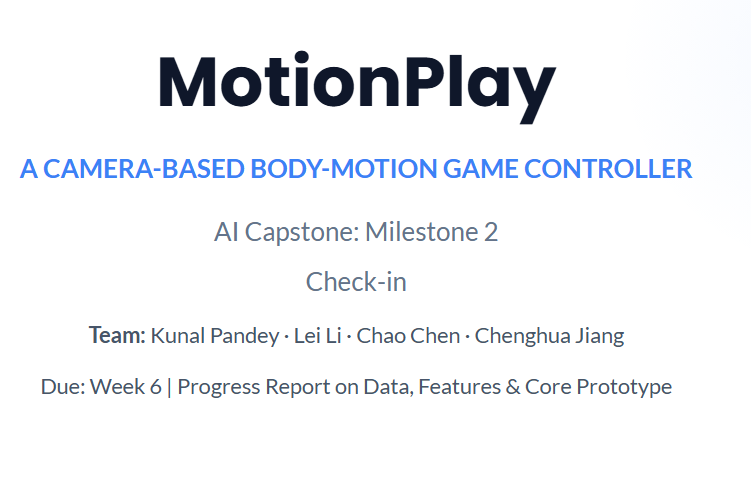

</div>     
</center> 

<div class="ppt-card">

# 1. 📓 Big Picture:

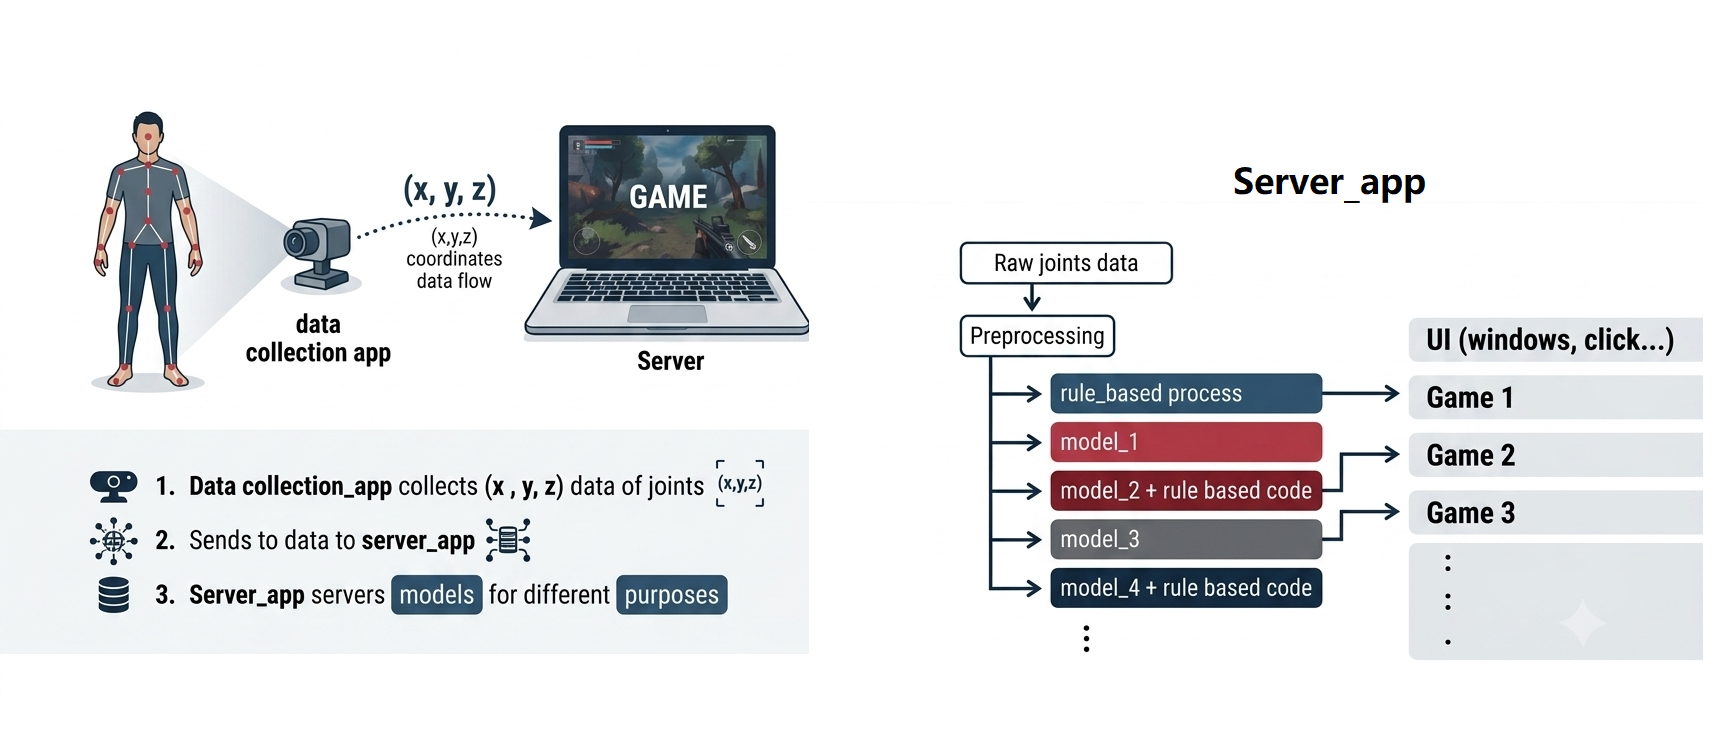

</div>

<div class="ppt-card">
    
# 2. ✨ System Components


#### 📱 Collection App
This module captures the player's physical movements in real-time.
* **Function:** Extracts 3D spatial coordinates from the camera feed.
* **Data Specification:** Tracks **91 body joints** using Apple’s ARKit [Details here](https://github.com/ouut/capstone_project/blob/master/doc/artkit_body_joint.en.md).
* **Data Modes:**
    * **Development:** Uses CSV files for offline testing and model validation [Example file](https://github.com/ouut/capstone_project/blob/master/doc/artkit_body_data_example.csv).
    * **Production:** Streams real-time data for live gameplay.

#### 🎮 Game Input API
A patched Switch simulator that supports UDP control.
* **Integration:** Translates AI-generated predictions into virtual controller inputs via UDP packets.
* **Demo:** A Jupyter Notebook script is used to demonstrate and verify the live connection [View script](https://github.com/ouut/eden_build/blob/overlay_cpp/scripts/game_controller.ipynb).

#### 🧠 AI Service (Processing Core)
The "brain" of the project, which interprets skeletal data to trigger specific in-game actions.
* **Workflow:** Receives coordinates → Performs model inference → Generates game controller commands.
* **Hybrid Logic:** Utilizes a combination of rule-based systems for simple triggers and machine learning models for complex gesture classification.

</div>

<div class="ppt-card">
    
# 3. 🚀 Technical Evolution Roadmap
 
Our technical strategy has evolved from low-level data processing to high-level feature extraction.

#### 01. End-to-End Deep Learning (Raw Video)
* **Concept:** Building a custom pose estimation model from scratch using raw video footage.
* **Key Focus:** Learning to identify and track body movements directly from pixels.

#### 02. Native API Integration (Skeleton Data)
* **Concept:** Integrating Apple’s native ARKit/Vision APIs.
* **Key Focus:** Utilizing built-in hardware capabilities to extract precise 3D skeleton coordinates, bypassing raw visual processing.

#### 03. Embedding-Based Recognition (Current State)
* **Concept:** Using pre-trained models to generate mathematical "embeddings" of human actions.
* **Key Focus:** Comparing in-game action vectors against a library of expert-level movements, eliminating the need for manual data collection.



### 📊 Comparison of Evolution Stages

| Stage | Approach | Advantages | Limitations |
| :--- | :--- | :--- | :--- |
| **01. Raw Video** | Direct video training | Full autonomy; custom-tailored. | Massive data/compute needs; slow. |
| **02. Native API** | ARKit skeletal data | High accuracy; no low-level CV. | Hardware locked; custom logic required. |
| **03. Embedding** | Feature vector matching | **Highest efficiency**; scalable. | Dependent on 3rd-party models. |

</div>

<div class="ppt-card">
    
# 4. 🏃 Baseline Model & Core Prototype

Implement a core prototype focusing on Spatio-Temporal Graph Convolutional Networks (ST-GCN) and a functional data pipeline.

#### 1 Prototype Implementation
* **Core Model:** Implemented a **Spatio-Temporal Graph Convolutional Network (ST-GCN)** from scratch using PyTorch. The model architecture consists of residual graph convolutional blocks followed by global pooling to handle full-body movement features.
* **Baseline Architecture:** The model treats the human skeleton as a graph, where joints are vertices and bones are edges, allowing it to capture both spatial dependencies (body structure) and temporal dynamics (movement over time).
* **Embeddings recognition:** A unified preprocessing pipeline has been established to handle both the public AIST++ dataset and our custom ARKit-based skeletal data - `[Not implemented]`.

#### 2 Initial Results & Performance for dance prediction - [Code Repol](https://github.com/ouut/capstone_project/tree/master/model)
* **Training Performance:** * **Dataset:** Pre-trained on 1,408 clips from the AIST++ public dataset (10 dance genres).
    * **Accuracy:** Achieved a training accuracy of **~93%** on the pre-training task.
    * **Convergence:** The loss function demonstrated smooth, stable convergence (final loss ~0.23), confirming the robustness of the graph-based approach.


</div>

<div class="ppt-card">
    
# 5. 🧪 Progress & Planning

#### 1 Progress Review (vs. Milestone 1 Plan)
* **Embedding-Based solution:** Completed the implementation of a Spatio-Temporal Graph Convolutional Network (ST-GCN) using PyTorch, achieving a ~93% training accuracy on the pre-training task.
* **System Integration:** Established the core data-flow foundation from ARKit coordinate generation to the server and then to the patched Switch emulator via UDP.

#### 2 Task Breakdown (Next 3 Weeks)
| Key | Core Tasks | Responsibility |
| :--- | :--- | :--- |
| **Data** | Record 5-gesture ARKit dataset; construct gesture-embedding bank from pre-trained backbone. | Kunal (Capture), Lei (Embedding) |
| **Service and model** | Improve the model performance and reduce the latency | Lei (ML), Chenghua (Metrics) |
| **Runnable** | Build low-latency iPhone-to-PC streaming & input emulation; execute live Mario-style demo control. | Chao (Systems), All (Integration) |


#### 3 Revised Risk Assessment
| Identified Risk | Mitigation Strategy |
| :--- | :--- |
| **Integration issues** | multiple components work together. |
| **[Domain Gap](https://github.com/ouut/capstone_project/blob/master/doc/Arkit_coco17_map_evaluation_EN.md)** | ensures AIST++ and custom ARKit data share an identical 12-joint topology. |
| **Latency** |  optimizing with lightweight UDP and 12-joint model compacting. |


</div>